In [35]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("diabetes_unclean.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


##PART 1: PREPROCESSING AND DATA CLEANING (PANDAS)
================================================================================

In [37]:
# 1) Drop the "ID" and "No_Pation" columns
df = df.drop("ID", axis=1)
df.head()

,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [38]:
df = df.drop("No_Pation", axis=1)
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [49]:
df['CLASS'].unique()

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

In [50]:
df['CLASS'] = df['CLASS'].replace('N ', 'N')
df['CLASS'] = df['CLASS'].replace('Y ', 'Y')
df['CLASS'].unique()

array(['N', 'P', 'Y'], dtype=object)

In [39]:
# 2) Display the unique values of the "Gender" column. If there are any misspelled values for 'F' and 'M', correct them
df["Gender"].unique()

array(['F', 'M', 'f'], dtype=object)

In [40]:
df['Gender'] = df['Gender'].replace('f', 'F')
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [41]:
# 3) Perform one-hot encoding on all categorical columns except the target variable
# Separate target column
target = df['CLASS']

# Features only
X = df.drop('CLASS', axis=1)

# One-hot encoding
X = pd.get_dummies(X)

# Add target back
df_coded = pd.concat([X, target], axis=1)

df_coded.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Gender_F,Gender_M,CLASS
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,N
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,False,True,N
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,N
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,N
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,False,True,N


In [42]:
# 4) Handle missing values using an appropriate method (drop rows, fill with mean, or
# fill with mode).

df_coded.isna().sum()

,0
AGE,1
Urea,1
Cr,2
HbA1c,3
Chol,2
TG,2
HDL,1
LDL,2
VLDL,1
BMI,0


In [43]:
df_coded = df_coded.fillna(df_coded.mean(numeric_only=True))
df_coded.isna().sum()

,0
AGE,0
Urea,0
Cr,0
HbA1c,0
Chol,0
TG,0
HDL,0
LDL,0
VLDL,0
BMI,0


## PART 2: EXPLORATORY DATA ANALYSIS (VISUALIZATIONS)

### Create the following plots using Matplotlib or Seaborn:

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

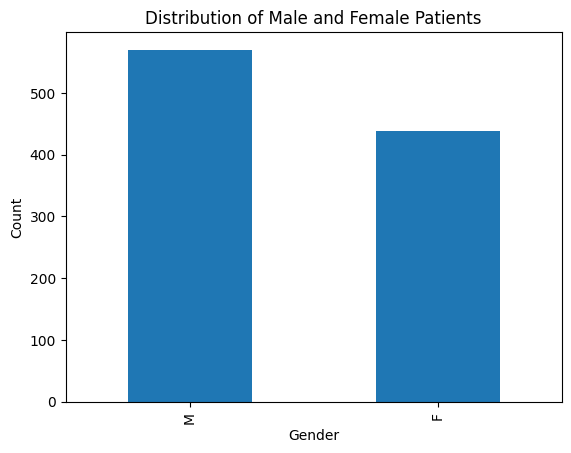

In [46]:
# 1) Bar chart showing the distribution of male and female patients
df['Gender'].value_counts().plot(kind='bar')

plt.title("Distribution of Male and Female Patients")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

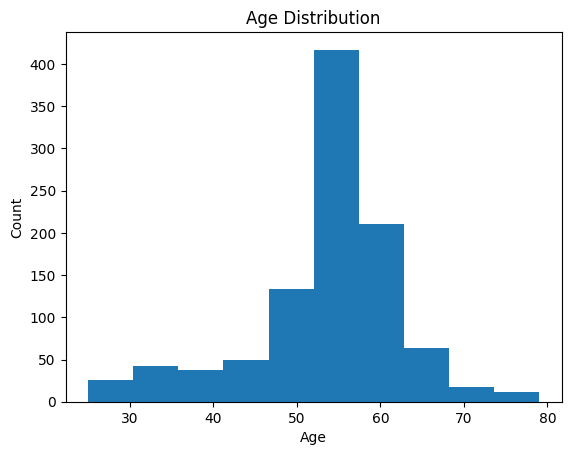

In [47]:
# 2) Histogram of age distribution
df['AGE'].plot(kind='hist')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

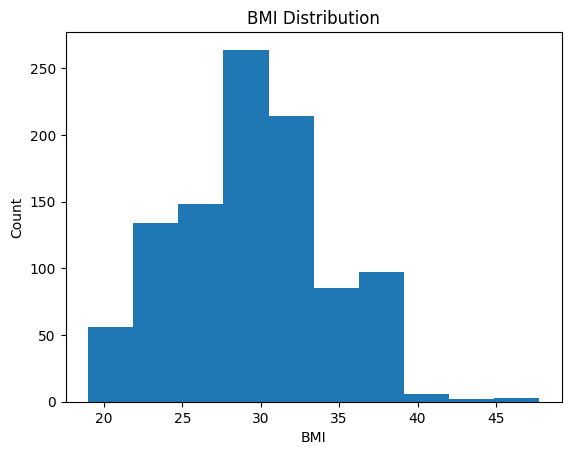

In [48]:
# 3) Histogram of BMI distribution
df['BMI'].plot(kind='hist')

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

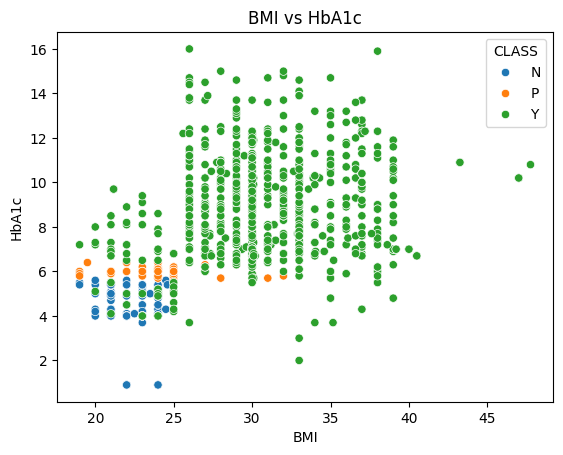

In [51]:
# 4) Scatter plot: BMI vs HbA1c (color-coded by diabetes class)
sns.scatterplot(x='BMI', y='HbA1c', hue='CLASS', data=df)

plt.title("BMI vs HbA1c")
plt.xlabel("BMI")
plt.ylabel("HbA1c")
plt.show()


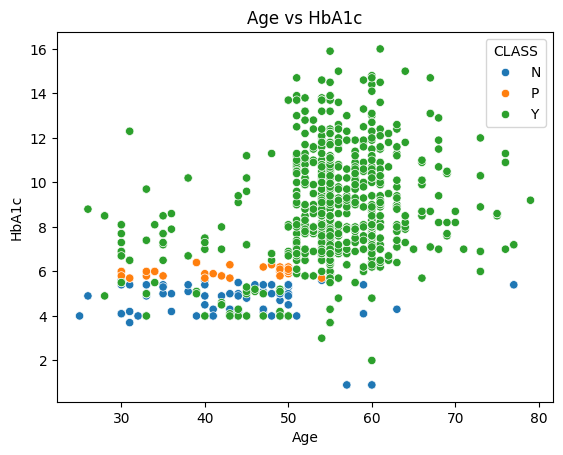

In [52]:
# 5) Scatter plot: Age vs HbA1c (color-coded by diabetes class)
sns.scatterplot(x='AGE', y='HbA1c', hue='CLASS', data=df)

plt.title("Age vs HbA1c")
plt.xlabel("Age")
plt.ylabel("HbA1c")
plt.show()


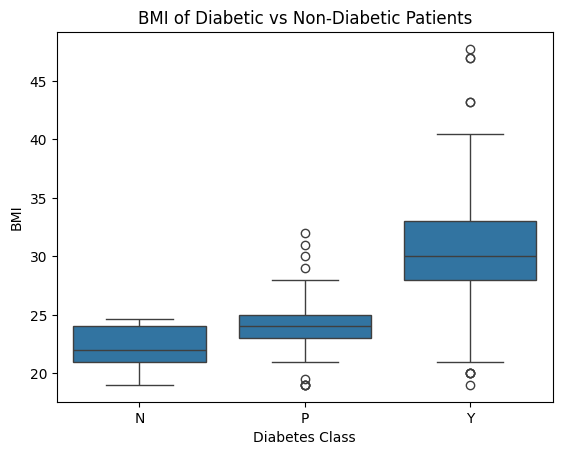

In [53]:
# 6) Box plot comparing BMI of diabetic vs non-diabetic patients
sns.boxplot(x='CLASS', y='BMI', data=df)

plt.title("BMI of Diabetic vs Non-Diabetic Patients")
plt.xlabel("Diabetes Class")
plt.ylabel("BMI")
plt.show()